In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from tqdm import tqdm
import csv
import gc
from scipy.stats import sem, t



In [2]:
# Load the DataFrames with the escape character specified
df_videos = pd.read_csv("/kaggle/input/final-data/videos_all.csv", escapechar='\\')
df_comments = pd.read_parquet("/kaggle/input/final-data/comments_all.parquet", engine="pyarrow")
df_speeches = pd.read_csv("/kaggle/input/final-data/speeches.csv")
df_twitter = pd.read_csv("/kaggle/input/final-data/twitter.csv")

/tmp/ipykernel_18/1772628603.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_speeches = pd.read_csv("/kaggle/input/final-data/speeches.csv")


In [3]:
df_speeches['leaning'] = df_speeches['leaning'].str.lower()
df_twitter['leaning'] = df_twitter['leaning'].str.lower()

In [4]:
df_videos.keys()

Index(['channel_id', 'channel_name', 'channel_leaning', 'video_id',
       'video_title', 'video_published_at', 'transcript', 'video_published',
       'descriptions', 'tags', 'categories', 'live', 'durations', 'captions',
       'views', 'likes', 'favorites', 'comments', 'duration_minutes',
       'political_probability', 'length', 'evidence_score_w2vparliament',
       'intuition_score_w2vparliament', 'length_bin',
       'evidence_mean_w2vparliament', 'evidence_adj_w2vparliament',
       'intuition_mean_w2vparliament', 'intuition_adj_w2vparliament',
       'evidence_z_w2vparliament', 'intuition_z_w2vparliament',
       'emi_w2vparliament', 'evidence_score_w2vfasttext',
       'intuition_score_w2vfasttext', 'evidence_mean_w2vfasttext',
       'evidence_adj_w2vfasttext', 'intuition_mean_w2vfasttext',
       'intuition_adj_w2vfasttext', 'evidence_z_w2vfasttext',
       'intuition_z_w2vfasttext', 'emi_w2vfasttext', 'channel_leaning_encoded',
       'transcript_clean', 'hs_ratio_x', 'tox

In [5]:
df_speeches.keys()

Index(['id', 'begin', 'end', 'text', 'date', 'session', 'electoralTerm',
       'firstName', 'lastName', 'politicianId', 'factionId', 'documentUrl',
       'positionShort', 'positionLong', 'length', 'chunk_length',
       'evidence_score', 'intuition_score', 'chunk_length_bin',
       'evidence_mean_x', 'evidence_adj', 'intuition_mean_x', 'intuition_adj',
       'evidence_z', 'intuition_z', 'emi', 'evidence_score_w2vparliament',
       'intuition_score_w2vparliament', 'length_bin',
       'evidence_mean_w2vparliament', 'evidence_adj_w2vparliament',
       'intuition_mean_w2vparliament', 'intuition_adj_w2vparliament',
       'evidence_z_w2vparliament', 'intuition_z_w2vparliament',
       'emi_w2vparliament', 'evidence_score_w2vfasttext',
       'intuition_score_w2vfasttext', 'evidence_mean_w2vfasttext',
       'evidence_adj_w2vfasttext', 'intuition_mean_w2vfasttext',
       'intuition_adj_w2vfasttext', 'evidence_z_w2vfasttext',
       'intuition_z_w2vfasttext', 'emi_w2vfasttext', 'abbre

In [6]:
df_twitter.keys()

Index(['id', 'author_id', 'created_at', 'party', 'reply', 'text',
       'retweet_count', 'reply_count', 'like_count', 'expanded_urls',
       'retweeted', 'quote_count', 'leaning', 'text_clean', 'length',
       'evidence_score_w2vparliament', 'intuition_score_w2vparliament',
       'length_bin', 'evidence_mean_w2vparliament',
       'evidence_adj_w2vparliament', 'intuition_mean_w2vparliament',
       'intuition_adj_w2vparliament', 'evidence_z_w2vparliament',
       'intuition_z_w2vparliament', 'emi_w2vparliament',
       'evidence_score_w2vfasttext', 'intuition_score_w2vfasttext',
       'evidence_mean_w2vfasttext', 'evidence_adj_w2vfasttext',
       'intuition_mean_w2vfasttext', 'intuition_adj_w2vfasttext',
       'evidence_z_w2vfasttext', 'intuition_z_w2vfasttext', 'emi_w2vfasttext',
       'evidence_mean', 'evidence_median', 'evidence_ci_low',
       'evidence_ci_high', 'intuition_mean', 'intuition_median',
       'intuition_ci_low', 'intuition_ci_high'],
      dtype='object')

Twitter
                                                Pair  Correlation  P-Value  \
0               emi_w2vparliament vs emi_w2vfasttext     0.649031      0.0   
1  intuition_score_w2vparliament vs intuition_sco...     0.518339      0.0   
2  evidence_score_w2vparliament vs evidence_score...     0.603762      0.0   

   CI Lower  CI Upper  
0  0.647840  0.650287  
1  0.516945  0.519762  
2  0.602533  0.604985  
Speeches
                                                Pair  Correlation  P-Value  \
0               emi_w2vparliament vs emi_w2vfasttext     0.806802      0.0   
1  intuition_score_w2vparliament vs intuition_sco...     0.652266      0.0   
2  evidence_score_w2vparliament vs evidence_score...     0.582220      0.0   

   CI Lower  CI Upper  
0  0.805087  0.808430  
1  0.648370  0.655833  
2  0.577834  0.586208  
YouTube
                                                Pair  Correlation  P-Value  \
0               emi_w2vparliament vs emi_w2vfasttext     0.799950      0.0   
1

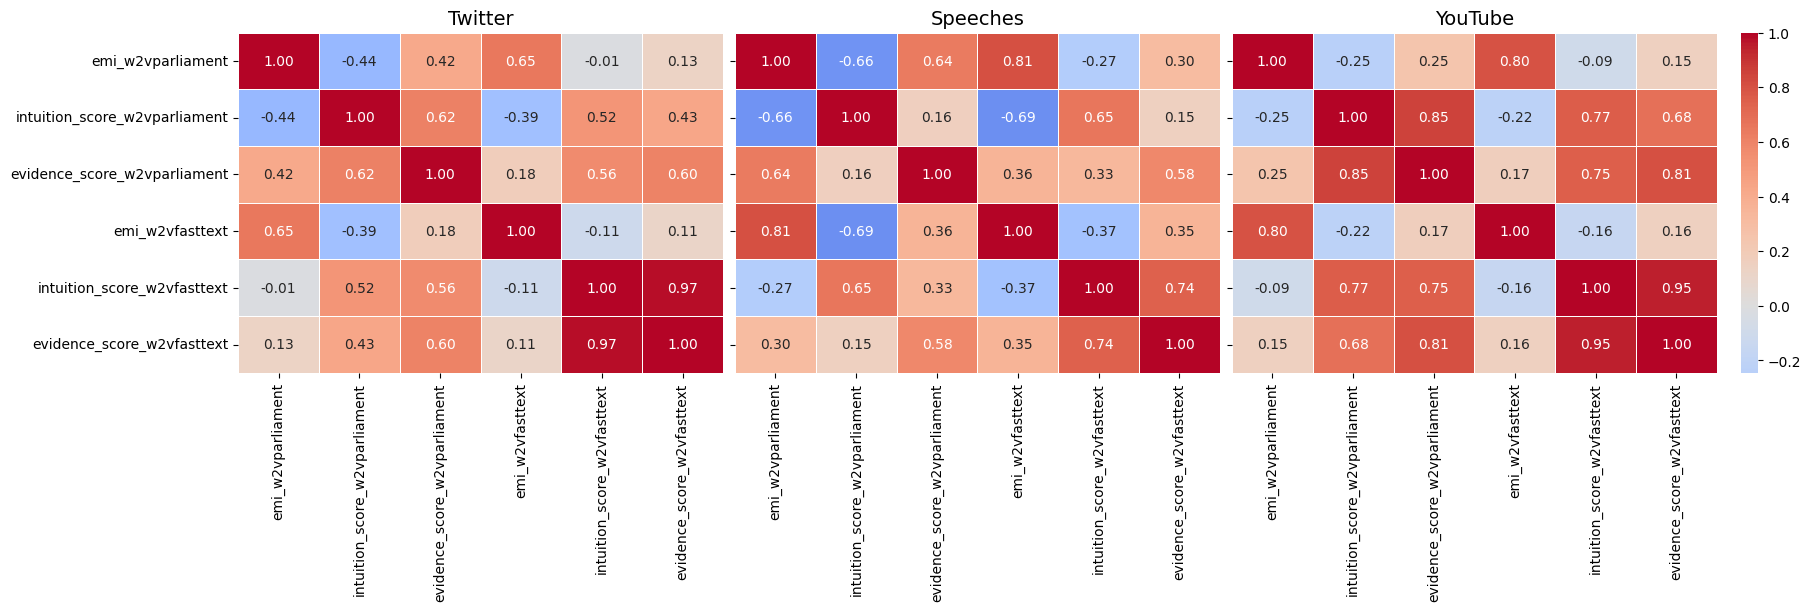

In [7]:
from scipy.stats import pearsonr

def bootstrap_corr_ci(data1, data2, func, num_samples=1000, ci=95):
    rng = np.random.default_rng()
    data = np.array(list(zip(data1, data2)))  # Combine data1 and data2 into paired rows
    estimates = [
        func(*zip(*rng.choice(data, size=len(data), replace=True)))[0]  # Resample rows together
        for _ in range(num_samples)
    ]
    lower_bound = np.percentile(estimates, (100 - ci) / 2)
    upper_bound = np.percentile(estimates, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound
    
# Define columns for correlation
columns_to_corr = [
    "emi_w2vparliament", "intuition_score_w2vparliament", "evidence_score_w2vparliament",
    "emi_w2vfasttext", "intuition_score_w2vfasttext", "evidence_score_w2vfasttext"
]

# Define pairs of columns for which to calculate Pearson correlation, p-values, and CIs
pairs = [
    ("emi_w2vparliament", "emi_w2vfasttext"),
    ("intuition_score_w2vparliament", "intuition_score_w2vfasttext"),
    ("evidence_score_w2vparliament", "evidence_score_w2vfasttext")
]

# Define datasets (assumed to be available in the environment)
datasets = {
    "Twitter": df_twitter,
    "Speeches": df_speeches,
    "YouTube": df_videos
}

# Create figure with 1 row, 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for i, (dataset_name, df) in enumerate(datasets.items()):
    # Compute correlation matrix
    corr_matrix = df[columns_to_corr].corr()

    # Plot heatmap
    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        linewidths=0.5, ax=axs[i], cbar=(i == 2)  # Only show colorbar on the last plot
    )

    # Set title for each heatmap
    axs[i].set_title(dataset_name, fontsize=14)

    # Remove x-ticks and y-ticks for middle and right plots
    if i > 0:
        axs[i].set_yticklabels([])
    else:
        axs[i].tick_params(axis='y', rotation=0)  # Keep y-ticks only for the first heatmap
    
    # Initialize results dictionary
    results = []

    # Calculate correlations, p-values, and confidence intervals
    for col1, col2 in pairs:
        # Drop NaN values
        data1 = df[col1].dropna()
        data2 = df[col2].dropna()
    
        # Ensure data alignment
        aligned_data = pd.concat([data1, data2], axis=1).dropna()
        data1, data2 = aligned_data[col1], aligned_data[col2]
    
        # Pearson correlation and p-value
        correlation, p_value = pearsonr(data1, data2)
    
        # Bootstrap confidence intervals
        ci_lower, ci_upper = bootstrap_corr_ci(data1.values, data2.values, pearsonr)
    
        # Append results
        results.append({
            "Pair": f"{col1} vs {col2}",
            "Correlation": correlation,
            "P-Value": p_value,
            "CI Lower": ci_lower,
            "CI Upper": ci_upper
        })

        # Convert results to DataFrame for display
        results_df = pd.DataFrame(results)
    print(dataset_name)
    print(results_df)


# Save and show
plt.savefig("correlation_matrices_all_datasets.png")
plt.show()

In [8]:
df_videos["leaning"] = df_videos["channel_leaning"]
# Define the updated palette
color_map = {
    "left": "#E66101",       # Orange-Red
    "middle": "#4D4D4D",     # Dark Gray
    "right": "#0072B2",      # Blue
    "news/science": "#F0E442",  # Bright Yellow
}

marker_map = {
    "left": "o",
    "middle": "s",
    "right": "^",
    "news/science": "d",  # Diamond marker for science/news
}

In [9]:
#df_videos = df_videos.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
df_videos['published'] = pd.to_datetime(df_videos['video_published'], errors='coerce')

df_twitter["published"] = pd.to_datetime(df_twitter['created_at'], errors='coerce')

df_speeches["published"] = pd.to_datetime(df_speeches['date'], errors='coerce')

In [10]:
# Define datasets (assumed to be available in the environment)
datasets = {
    "Twitter": df_twitter,
    "Speeches": df_speeches,
    "YouTube": df_videos
}

In [11]:
# Define a function to perform bootstrapping and calculate confidence intervals
def bootstrap_ci(data, num_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(num_bootstrap):
        sample = data.sample(frac=1, replace=True)
        boot_means.append(sample.mean())
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound


/tmp/ipykernel_18/1188003002.py:23: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_avg = rolling_avg.resample('Q').mean()
/tmp/ipykernel_18/1188003002.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  leaning_data['published'].dt.to_period('Q') == quarter.to_period('Q')
/tmp/ipykernel_18/1188003002.py:31: UserWarning: Converting to Period representation will drop timezone information.
  leaning_data['published'].dt.to_period('Q') == quarter.to_period('Q')


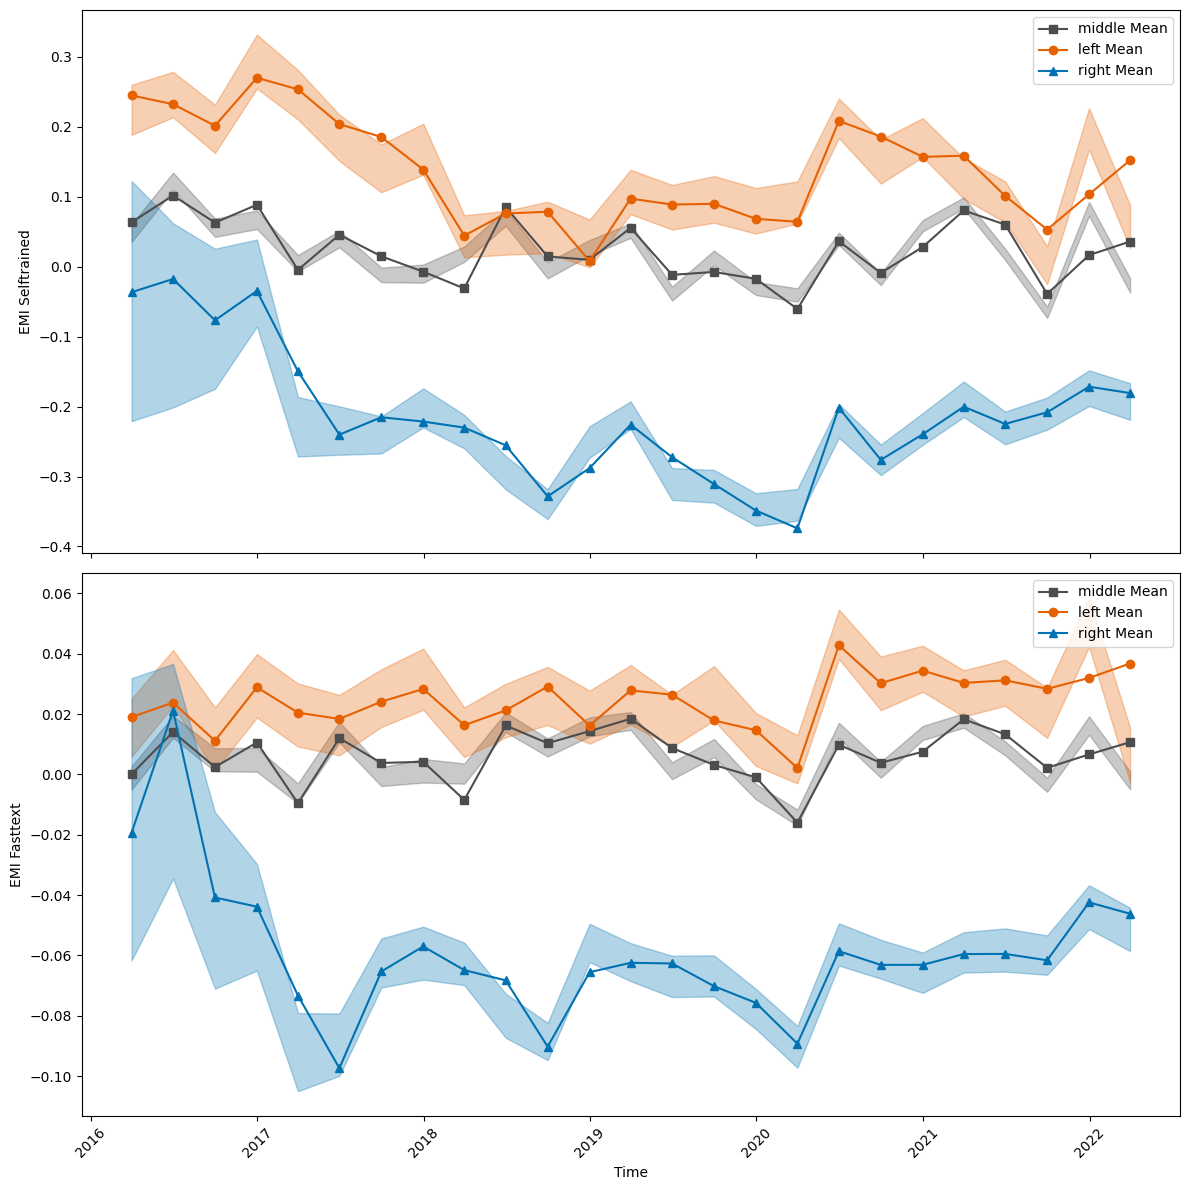

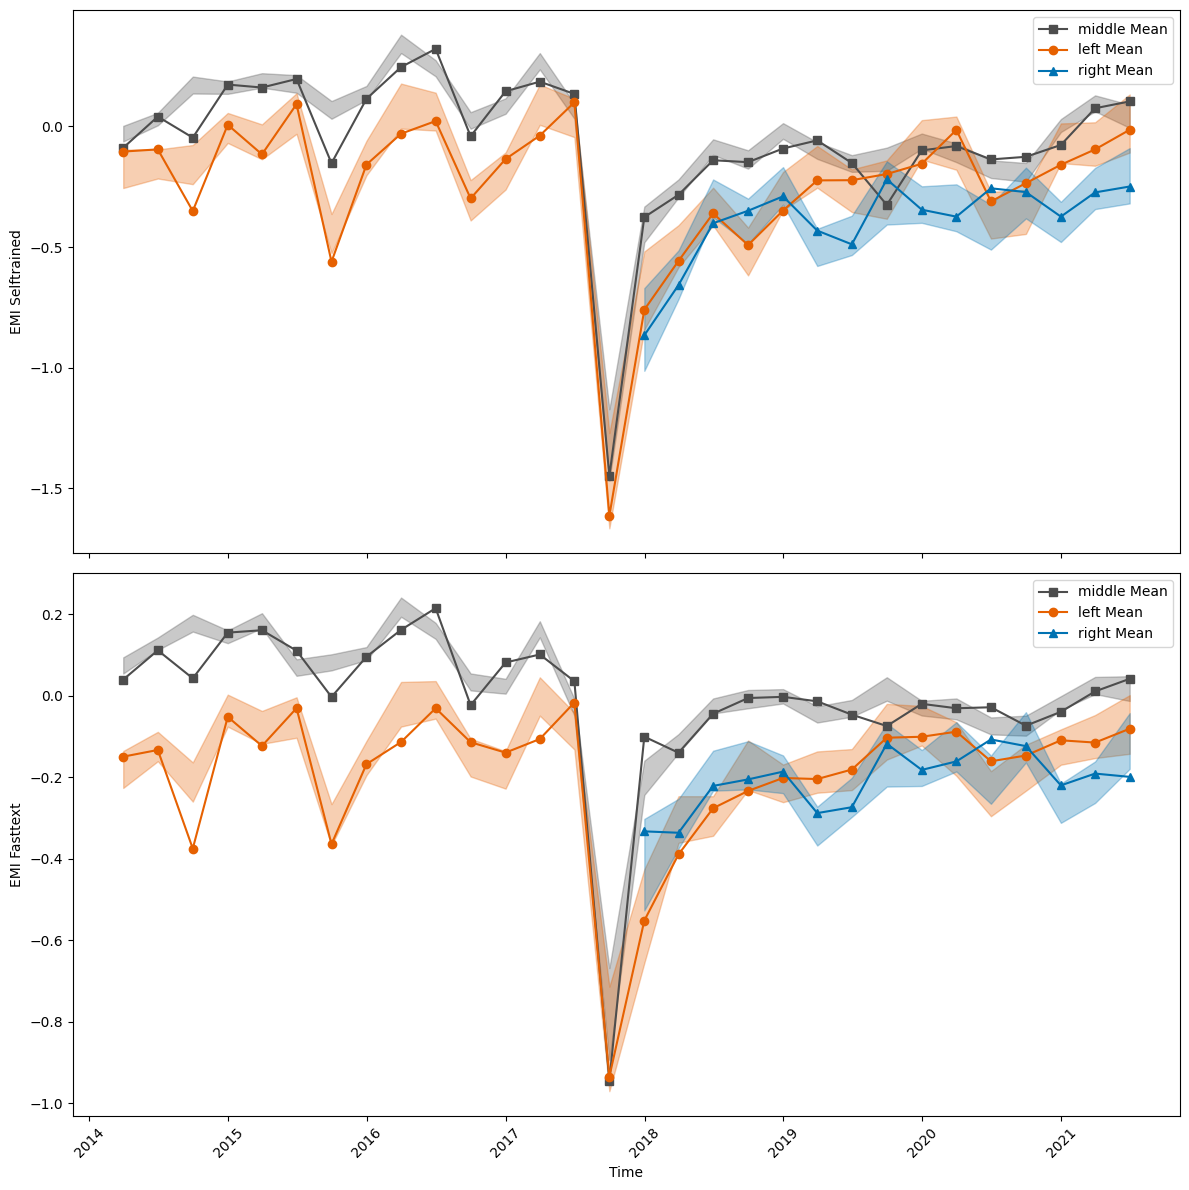

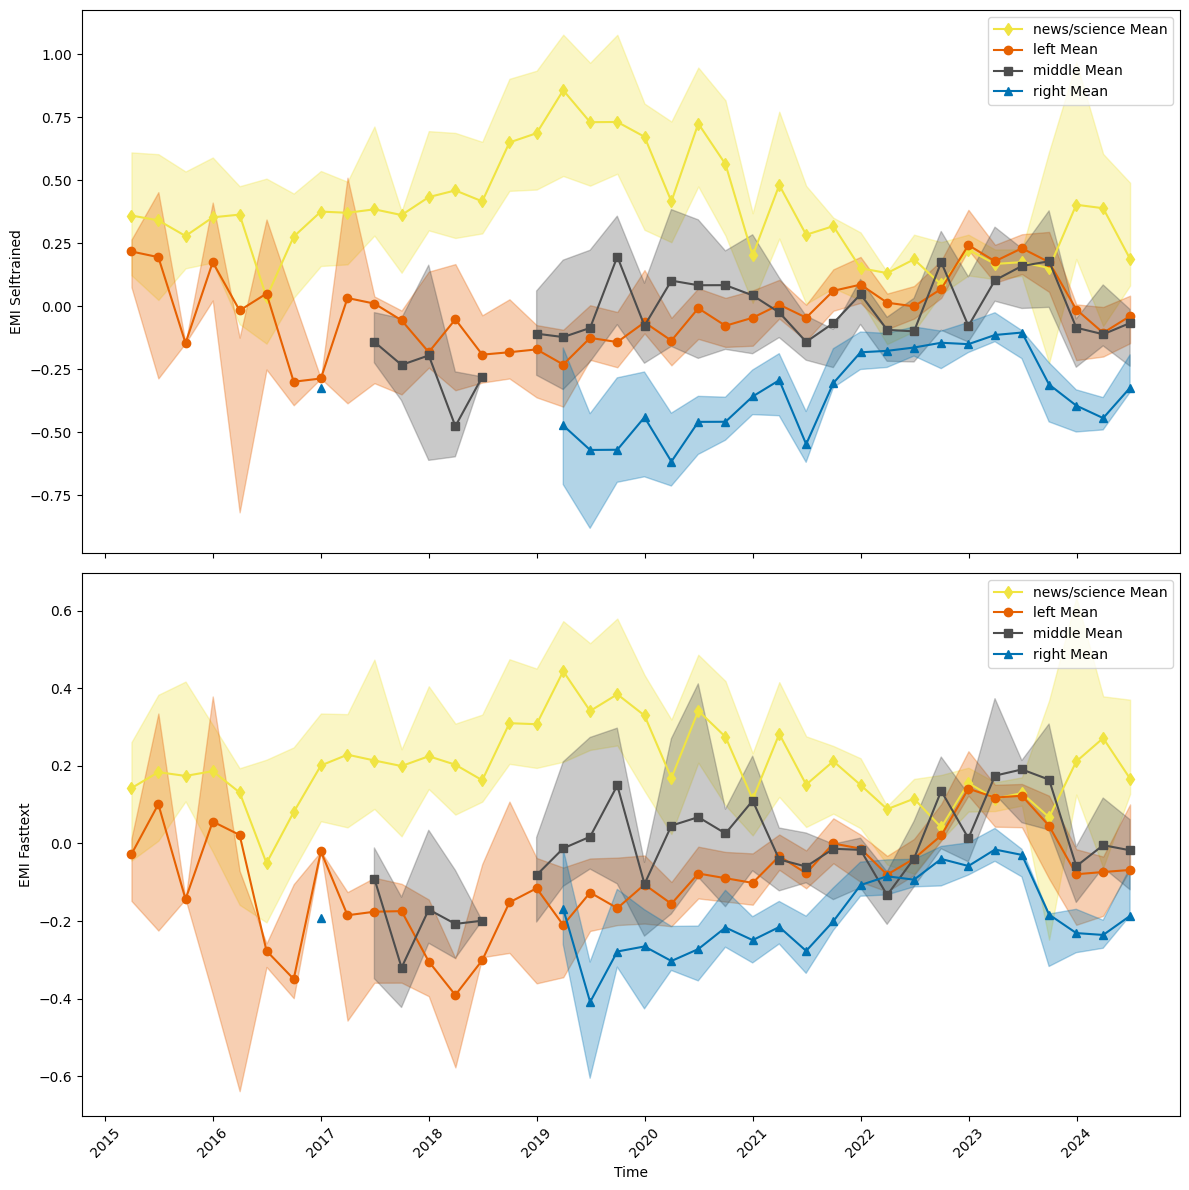

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is already loaded and contains 'video_published_at' as a datetime column
score_columns = ["emi_w2vparliament", "emi_w2vfasttext"]


for i, (dataset_name, df) in enumerate(datasets.items()):
    
    fig, axes = plt.subplots(nrows=len(score_columns), ncols=1, figsize=(12, 6 * len(score_columns)), sharex=True)
    
    if len(score_columns) == 1:
        axes = [axes]  # Ensure axes is iterable if only one score column exists
    
    for idx, score in enumerate(score_columns):
        ax = axes[idx]
        
        for leaning in df['leaning'].unique():
            leaning_data = df[df['leaning'] == leaning].sort_values('published')
        
            # Calculate a 2-month rolling mean and then resample by quarter
            rolling_avg = leaning_data.set_index('published')[score].rolling('60D').mean()
            quarterly_avg = rolling_avg.resample('Q').mean()
    
            lower_bounds = []
            upper_bounds = []
    
            for quarter in quarterly_avg.index:
                # Get data for the specific quarter and calculate bootstrap confidence interval
                quarterly_data = leaning_data[
                    leaning_data['published'].dt.to_period('Q') == quarter.to_period('Q')
                ]
                lower, upper = bootstrap_ci(quarterly_data[score].dropna())
                lower_bounds.append(lower)
                upper_bounds.append(upper)
    
            lower_bounds = pd.Series(lower_bounds, index=quarterly_avg.index)
            upper_bounds = pd.Series(upper_bounds, index=quarterly_avg.index)
    
            ax.plot(
                quarterly_avg.index,
                quarterly_avg,
                label=f'{leaning} Mean',
                color=color_map[leaning],
                marker=marker_map[leaning]
            )
            ax.fill_between(
                quarterly_avg.index,
                lower_bounds,
                upper_bounds,
                color=color_map[leaning],
                alpha=0.3
            )
        if idx == 0:
            ax.set_ylabel('EMI Selftrained')
        else:
            ax.set_ylabel('EMI Fasttext')
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
    
    # Adding common labels
    axes[-1].set_xlabel('Time')
    plt.tight_layout()
    
    # Save and show plot
    plt.savefig(f"model_timeline{dataset_name}.png")
    plt.show()
